In [1]:
import pandas as pd


In [2]:
data=pd.read_csv('beer-servings.csv')
data.head()

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa


In [3]:
data.drop(columns=['Unnamed: 0', 'country', 'continent'], inplace=True)

In [4]:
data.head()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,0.0,0.0,0.0,0.0
1,89.0,132.0,54.0,4.9
2,25.0,0.0,14.0,0.7
3,245.0,138.0,312.0,12.4
4,217.0,57.0,45.0,5.9


In [5]:
data.isnull().sum()

,0
beer_servings,8
spirit_servings,8
wine_servings,6
total_litres_of_pure_alcohol,1


In [6]:
data.duplicated().sum()

np.int64(12)

In [7]:
data.drop_duplicates(inplace=True)

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.fillna(data.mean(), inplace=True)

In [10]:
data.isnull().sum()

,0
beer_servings,0
spirit_servings,0
wine_servings,0
total_litres_of_pure_alcohol,0


In [11]:
X=data.drop(columns=['total_litres_of_pure_alcohol'])
y=data['total_litres_of_pure_alcohol']

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.25, random_state=42)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [14]:
model = Sequential()
model.add(Input(shape=(3,)))
model.add(Dense(5, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(1, activation='relu'))


In [15]:
model.compile(optimizer='adam', loss='mse', metrics=['r2_score'])

In [16]:
history=model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test))

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 146.1765 - r2_score: -11.8702 - val_loss: 86.1281 - val_r2_score: -3.9925
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 73.7329 - r2_score: -5.2901 - val_loss: 61.0381 - val_r2_score: -2.5381
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 72.7512 - r2_score: -5.2449 - val_loss: 46.9873 - val_r2_score: -1.7237
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 45.4126 - r2_score: -2.7372 - val_loss: 40.7793 - val_r2_score: -1.3638
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 51.0699 - r2_score: -3.2780 - val_loss: 38.8041 - val_r2_score: -1.2493
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 41.2339 - r2_score: -2.6052 - val_loss: 39.8410 - val_r2_score: -1.3094
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 39.8258 - r2_score: -2.1510 - val_loss: 42.6322 - val_r2_score: -1.4712
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 36.8239 - r2_score: -2.0904 - 

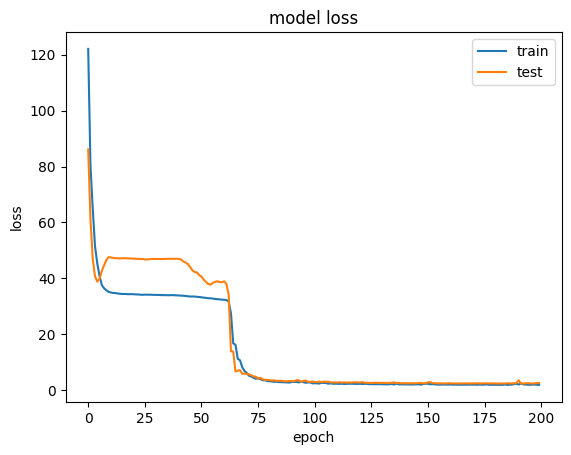

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [18]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.4082 - r2_score: 0.8662


[2.5383269786834717, 0.8528633117675781]

In [19]:
model.save("beer-servings.keras")

In [40]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris=load_iris()


In [41]:
X=iris["data"]
y=iris["target"]

In [42]:
import pandas as pd
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [43]:
X_test, X_train, y_test, y_train=train_test_split(X,y, test_size=0.2,random_state=42)


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [29]:
model= Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(20, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(3, activation='softmax'))


In [45]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [46]:
history=model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7667 - loss: 0.5632 - val_accuracy: 0.7917 - val_loss: 0.5691
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8000 - loss: 0.5567 - val_accuracy: 0.7917 - val_loss: 0.5629
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8000 - loss: 0.5505 - val_accuracy: 0.7917 - val_loss: 0.5570
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8000 - loss: 0.5443 - val_accuracy: 0.8000 - val_loss: 0.5514
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8000 - loss: 0.5383 - val_accuracy: 0.8000 - val_loss: 0.5458
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8000 - loss: 0.5324 - val_accuracy: 0.8000 - val_loss: 0.5403
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8000 - loss: 0.5266 - val_accuracy: 0.8000 - val_loss: 0.5346
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8000 - loss: 0.5209 - val_accuracy: 0.8000 - val_loss

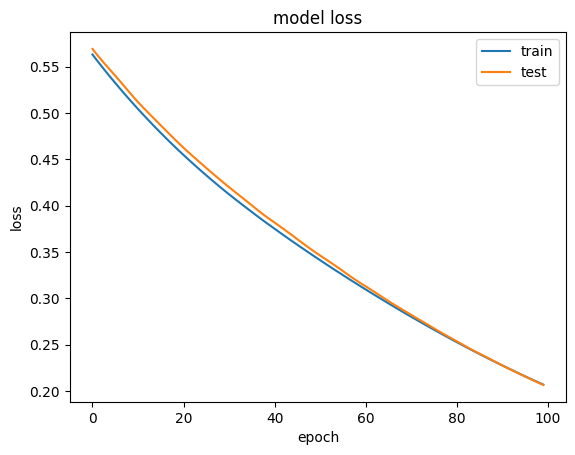

In [47]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [48]:
model.save("iris_classifier.keras")

In [49]:
import tensorflow as tf
model=tf.keras.models.load_model("iris_classifier.keras")

In [50]:
val_loss, val_acc=model.evaluate(X_test, y_test)
print("VALIDATION LOSS",val_loss)
print("VALIDATION ACCURACY",val_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9775 - loss: 0.1970 
VALIDATION LOSS 0.20643170177936554
VALIDATION ACCURACY 0.9750000238418579


In [54]:
import numpy as np
import matplotlib.pyplot as plt


# -------- Activation Classes -------- #

class Sigmoid:
    def forward(self, x):
        return 1 / (1 + np.exp(-x))


class ReLU:
    def forward(self, x):
        return np.maximum(0, x)


class Linear:
    def forward(self, x):
        return x


class Tanh:
    def forward(self, x):
        return np.tanh(x)


class Softmax:
    def forward(self, x):
        x = x - np.max(x)
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x)


# Input Range
x = np.linspace(-10, 10, 400)


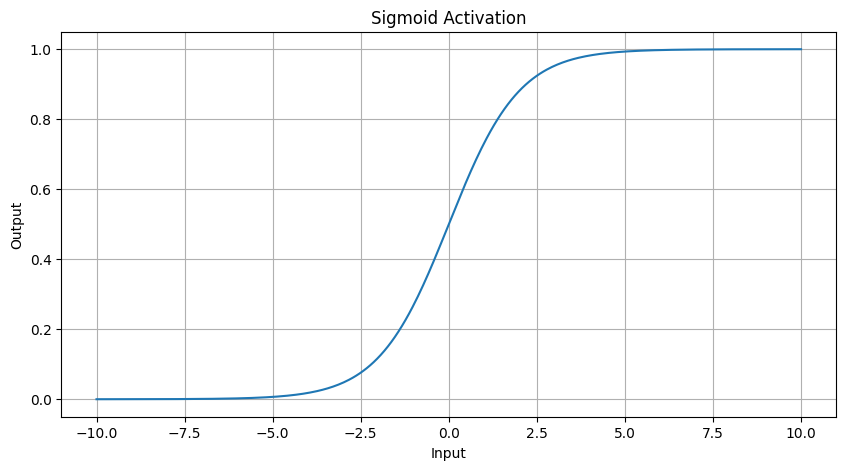

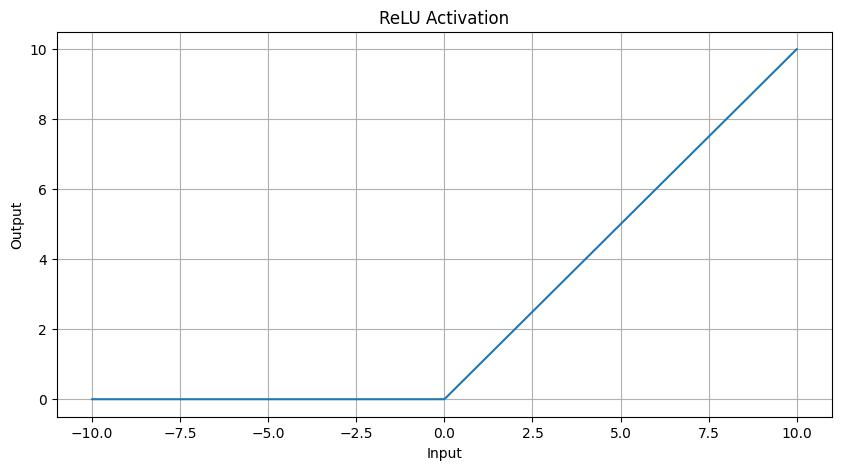

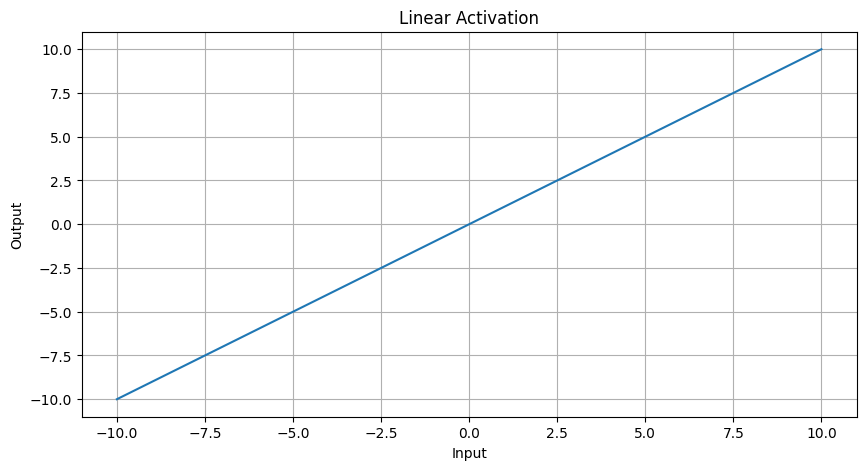

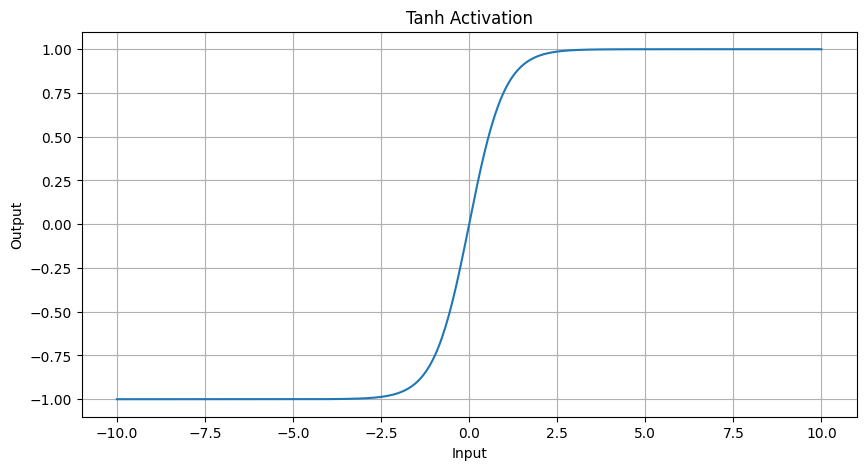

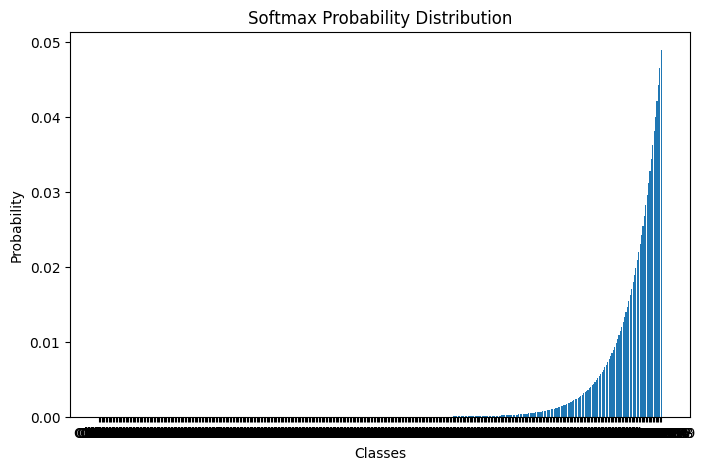

In [63]:
sigmoid = Sigmoid()

plt.figure(figsize=(10, 5))
plt.plot(x, sigmoid.forward(x))
plt.title("Sigmoid Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()


relu = ReLU()

plt.figure(figsize=(10, 5))
plt.plot(x, relu.forward(x))
plt.title("ReLU Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()


linear = Linear()

plt.figure(figsize=(10, 5))
plt.plot(x, linear.forward(x))
plt.title("Linear Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

tanh = Tanh()

plt.figure(figsize=(10, 5))
plt.plot(x, tanh.forward(x))
plt.title("Tanh Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

softmax = Softmax()
probabilities = softmax.forward(x)

# Plot probability distribution
classes = [f"Class {i}" for i in range(len(probabilities))]

plt.figure(figsize=(8,5))
plt.bar(classes, probabilities)

plt.title("Softmax Probability Distribution")
plt.xlabel("Classes")
plt.ylabel("Probability")
plt.show()



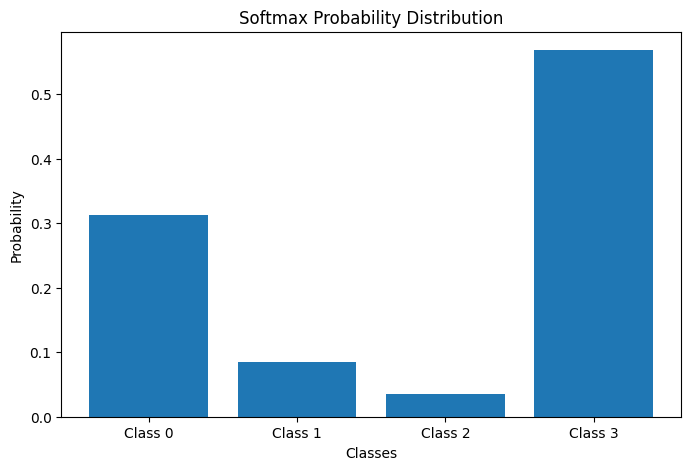

In [62]:
import numpy as np
import matplotlib.pyplot as plt


class Softmax:
    def forward(self, x):
        x = x - np.max(x)
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x)


# Example logits (raw NN outputs)
logits = np.array([2.5, 1.2, 0.3, 3.1])

softmax = Softmax()
probabilities = softmax.forward(logits)

# Plot probability distribution
classes = [f"Class {i}" for i in range(len(probabilities))]

plt.figure(figsize=(8,5))
plt.bar(classes, probabilities)

plt.title("Softmax Probability Distribution")
plt.xlabel("Classes")
plt.ylabel("Probability")
plt.show()


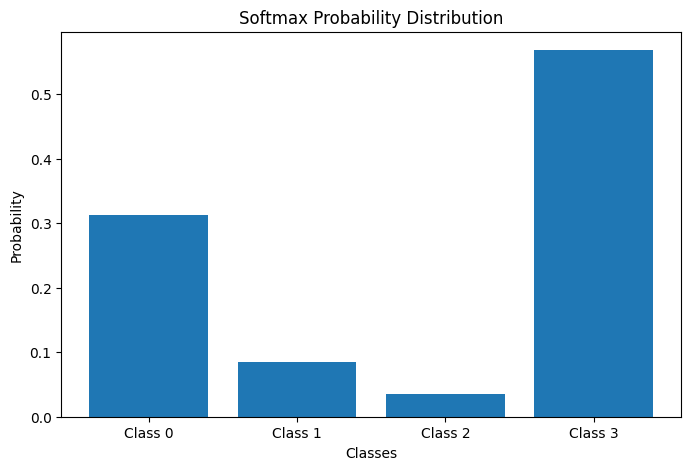

In [64]:
softmax = Softmax()
probabilities = softmax.forward(logits)

# Plot probability distribution
classes = [f"Class {i}" for i in range(len(probabilities))]

plt.figure(figsize=(8,5))
plt.bar(classes, probabilities)

plt.title("Softmax Probability Distribution")
plt.xlabel("Classes")
plt.ylabel("Probability")
plt.show()

In [67]:
np.sum(probabilities)

np.float64(1.0)

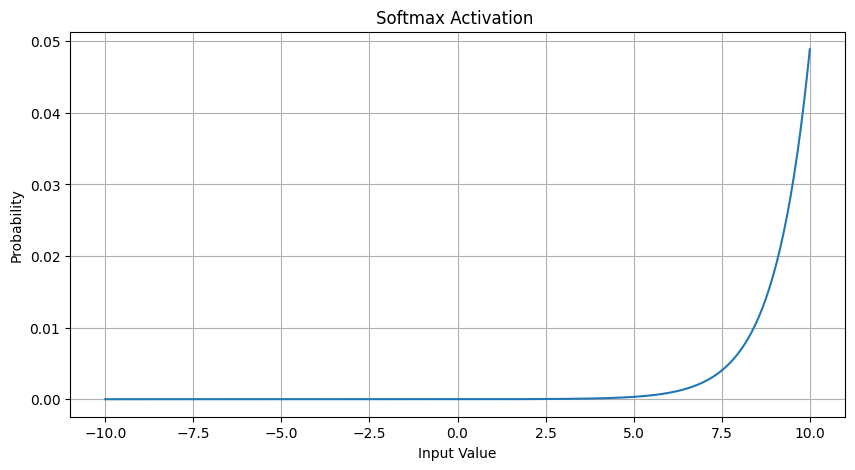

In [65]:

softmax = Softmax()


plt.figure(figsize=(10, 5))
plt.plot(x, softmax.forward(x))
plt.title("Softmax Activation ")
plt.xlabel("Input Value")
plt.ylabel("Probability")
plt.grid(True)
plt.show()

In [69]:
from tensorflow.python.client import device_lib

def get_available_devices():
    local_device_protos = device_lib.list_local_devices()
    return [x.name for x in local_device_protos]

print(get_available_devices())

['/device:CPU:0']
